In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from skimage.transform import radon, iradon
from scipy.signal.windows import hann
from tqdm import tqdm
from skimage.draw import disk
from PIL import Image


def niveau_bruit(image_in, SNR_db):
    P_image = np.mean(image_in ** 2)
    P_noise = P_image / (10 ** (SNR_db / 10))
    return np.sqrt(P_noise)


def afficher_tenseur_3d(tenseur_3d, reference=None):
    """
    Prend un tenseur 3D de forme (N, M, P) et l'affiche dans une grille
    de taille optimale avec 'Layer X' en titre.
    Si une image de référence est fournie, calcule et affiche la MSE et le PSNR.
    """
    P = tenseur_3d.shape[2]
    
    colonnes = math.ceil(math.sqrt(P))
    lignes = math.ceil(P / colonnes)
    
    fig, axes = plt.subplots(lignes, colonnes, figsize=(colonnes * 4, lignes * 4))
    
    if lignes * colonnes == 1:
        axes = np.array([axes])
    axes = axes.flatten()
        
    for i in range(P):
        couche = tenseur_3d[:, :, i]
        axes[i].imshow(couche, cmap='gray', aspect='auto')
        
        titre = f'Layer {i}'
        if reference is not None:
            mse = np.mean((couche - reference) ** 2)
            if mse > 0:
                data_range = np.max(reference) - np.min(reference)
                data_range = data_range if data_range > 0 else 1.0
                psnr = 10 * np.log10((data_range ** 2) / mse)
                titre += f'\nMSE: {mse:.4f} | PSNR: {psnr:.1f} dB'
            else:
                titre += '\nMSE: 0.0000 | PSNR: Inf dB'
                
        axes[i].set_title(titre, fontsize=10)
        axes[i].axis('off')
        
    for j in range(P, lignes * colonnes):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()


def extraction_rang_1_hopm(tenseur_3d, nb_iterations=15):
    """
    Extrait la composante de rang 1 d'un tenseur 3D (HOPM)
    et reconstruit la matrice 2D dominante.
    Correspond au bloc "Tensor rank-1 decomposition" du schéma.
    """
    D1, D2, D3 = tenseur_3d.shape
    
    u1 = np.random.rand(D1)
    u2 = np.random.rand(D2)
    u3 = np.random.rand(D3)
    
    u2 /= np.linalg.norm(u2) + 1e-8
    u3 /= np.linalg.norm(u3) + 1e-8
    
    for _ in range(nb_iterations):
        u1 = np.einsum('ijk,j,k->i', tenseur_3d, u2, u3)
        u1 /= np.linalg.norm(u1) + 1e-8
        
        u2 = np.einsum('ijk,i,k->j', tenseur_3d, u1, u3)
        u2 /= np.linalg.norm(u2) + 1e-8
        
        u3 = np.einsum('ijk,i,j->k', tenseur_3d, u1, u2)
        poids = np.linalg.norm(u3) 
        u3 /= poids + 1e-8
        
    matrice_f_2d = poids * np.outer(u1, u2)
    return matrice_f_2d


def pipeline_echographie_complet(tenseur_images, angles_radon, taille_fenetre=40, step=10, reference=None):
    """
    Exécute le pipeline complet : Radon fenêtré -> Tenseur -> Iradon -> Overlap-Add
    Affiche les étapes intermédiaires sur une grille 2x3 pour le patch central.
    """
    N, M, P = tenseur_images.shape
    demi = taille_fenetre // 2
    
    pad_x, pad_y = demi, demi
    tenseur_pad = np.pad(
        tenseur_images, 
        pad_width=((pad_x, pad_x), (pad_y, pad_y), (0, 0)), 
        mode='reflect'
    )
    N_pad, M_pad, _ = tenseur_pad.shape
    
    fenetre_1d = hann(taille_fenetre)
    fenetre_2d = np.outer(fenetre_1d, fenetre_1d)
    fenetre_3d = fenetre_2d[:, :, np.newaxis]
    
    accumulateur_image = np.zeros((N_pad, M_pad))
    accumulateur_poids = np.zeros((N_pad, M_pad))
    
    nx = math.ceil(N / step)
    ny = math.ceil(M / step)
    total_patchs = nx * ny
    
    centre_x_idx = nx // 2
    centre_y_idx = ny // 2
    
    with tqdm(total=total_patchs, desc="Traitement du Pipeline", unit="patch") as pbar:
        for idx_x in range(nx):
            for idx_y in range(ny):
                
                start_x, start_y = idx_x * step, idx_y * step
                end_x, end_y = start_x + taille_fenetre, start_y + taille_fenetre
                
                if end_x > N_pad or end_y > M_pad:
                    pbar.update(1)
                    continue
                
                patch_spatial = tenseur_pad[start_x:end_x, start_y:end_y, :]
                patch_fenetre = patch_spatial * fenetre_3d
                
                sino_test = radon(patch_fenetre[:, :, 0], theta=angles_radon, circle=False)
                dim_radon, nb_angles = sino_test.shape
                
                patch_radon_3d = np.zeros((dim_radon, nb_angles, P))
                patch_radon_3d[:, :, 0] = sino_test
                for p in range(1, P):
                    patch_radon_3d[:, :, p] = radon(patch_fenetre[:, :, p], theta=angles_radon, circle=False)
                
                matrice_f = extraction_rang_1_hopm(patch_radon_3d, nb_iterations=15)
                
                patch_reconstruit_2d = iradon(
                    matrice_f, 
                    theta=angles_radon, 
                    circle=False, 
                    output_size=taille_fenetre
                )
                
                if idx_x == centre_x_idx and idx_y == centre_y_idx:
                    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
                    axs = axs.flatten()
                    
                    if reference is not None:
                        axs[0].imshow(reference, cmap='gray')
                        axs[0].set_title("0. Global Image\n(Clean Reference)")
                        rect_x = start_y - pad_y
                        rect_y = start_x - pad_x
                        rect = patches.Rectangle((rect_x, rect_y), taille_fenetre, taille_fenetre, 
                                                 linewidth=2, edgecolor='r', facecolor='none')
                        axs[0].add_patch(rect)
                    else:
                        axs[0].text(0.5, 0.5, "No Reference Provided", ha='center', va='center')
                        axs[0].set_title("0. Global Image\n(Clean Reference)")
                        
                    axs[0].set_xlabel("x-axis")
                    axs[0].set_ylabel("z-axis")

                    axs[1].imshow(tenseur_pad[:, :, 0], cmap='gray')
                    axs[1].set_title("1. Noisy Input Layer 0\n(Padded Image)")
                    rect = patches.Rectangle((start_y, start_x), taille_fenetre, taille_fenetre, 
                                             linewidth=2, edgecolor='r', facecolor='none')
                    axs[1].add_patch(rect)
                    axs[1].set_xlabel("x-axis")
                    axs[1].set_ylabel("z-axis")

                    axs[2].imshow(patch_fenetre[:, :, 0], cmap='gray')
                    axs[2].set_title("2. Measurement\n(Patch Spatial Noisy)")
                    axs[2].set_xlabel("x-axis")
                    axs[2].set_ylabel("z-axis")
                    
                    axs[3].imshow(patch_radon_3d[:, :, 0], cmap='gray', aspect='auto')
                    axs[3].set_title("3. Radon transform\n(Couche 0)")
                    axs[3].set_xlabel("Rx angle")
                    axs[3].set_ylabel("Displacement d")
                    
                    axs[4].imshow(matrice_f, cmap='gray', aspect='auto')
                    axs[4].set_title("4. Tensor rank-1 dec.\n(Matrice f)")
                    axs[4].set_xlabel("mid angle")
                    axs[4].set_ylabel("Displacement d")
                    
                    axs[5].imshow(patch_reconstruit_2d, cmap='gray')
                    axs[5].set_title("5. Backprojection\n(Patch Reconstruit)")
                    axs[5].set_xlabel("x-axis")
                    axs[5].set_ylabel("z-axis")
                    
                    plt.tight_layout()
                    plt.show()
                
                accumulateur_image[start_x:end_x, start_y:end_y] += patch_reconstruit_2d
                accumulateur_poids[start_x:end_x, start_y:end_y] += fenetre_2d
                
                pbar.update(1)

    masque = accumulateur_poids > 1e-8
    accumulateur_image[masque] /= accumulateur_poids[masque]
    
    image_finale_debruitee = accumulateur_image[pad_x : pad_x + N, pad_y : pad_y + M]
    
    return image_finale_debruitee


def pipeline_sur_image(base_image, layers=9, SNR_db=10.0):
    print("Génération des données...")
    (N, M), P = base_image.shape, layers

    ecart_type_bruit = niveau_bruit(base_image, SNR_db=SNR_db)
    
    print(f"SNR cible : {SNR_db} dB -> Écart-type du bruit généré : {ecart_type_bruit:.4f}")

    tenseur_entree = np.repeat(base_image[:, :, np.newaxis], P, axis=2)
    bruit = np.random.normal(0, ecart_type_bruit, tenseur_entree.shape)
    tenseur_entree += tenseur_entree * bruit

    angles_projection = np.linspace(0., 180., 90, endpoint=False)
    taille_fenetre_glissante = 32
    pas_glissement = 8

    print(f"\nLancement du pipeline sur un tenseur {tenseur_entree.shape}...")
    image_resultat = pipeline_echographie_complet(
        tenseur_images=tenseur_entree,
        angles_radon=angles_projection,
        taille_fenetre=taille_fenetre_glissante,
        step=pas_glissement,
        reference=base_image
    )

    print("\n--- Terminé ! ---")
    print(f"Taille de l'image de sortie : {image_resultat.shape} (Attendue: {N}, {M})")

    return image_resultat, tenseur_entree

Génération des données...
SNR cible : 1 dB -> Écart-type du bruit généré : 0.2524

Lancement du pipeline sur un tenseur (200, 200, 9)...


Traitement du Pipeline:   0%|          | 0/625 [00:00<?, ?patch/s]

Traitement du Pipeline:  50%|████▉     | 312/625 [00:19<00:22, 14.05patch/s]

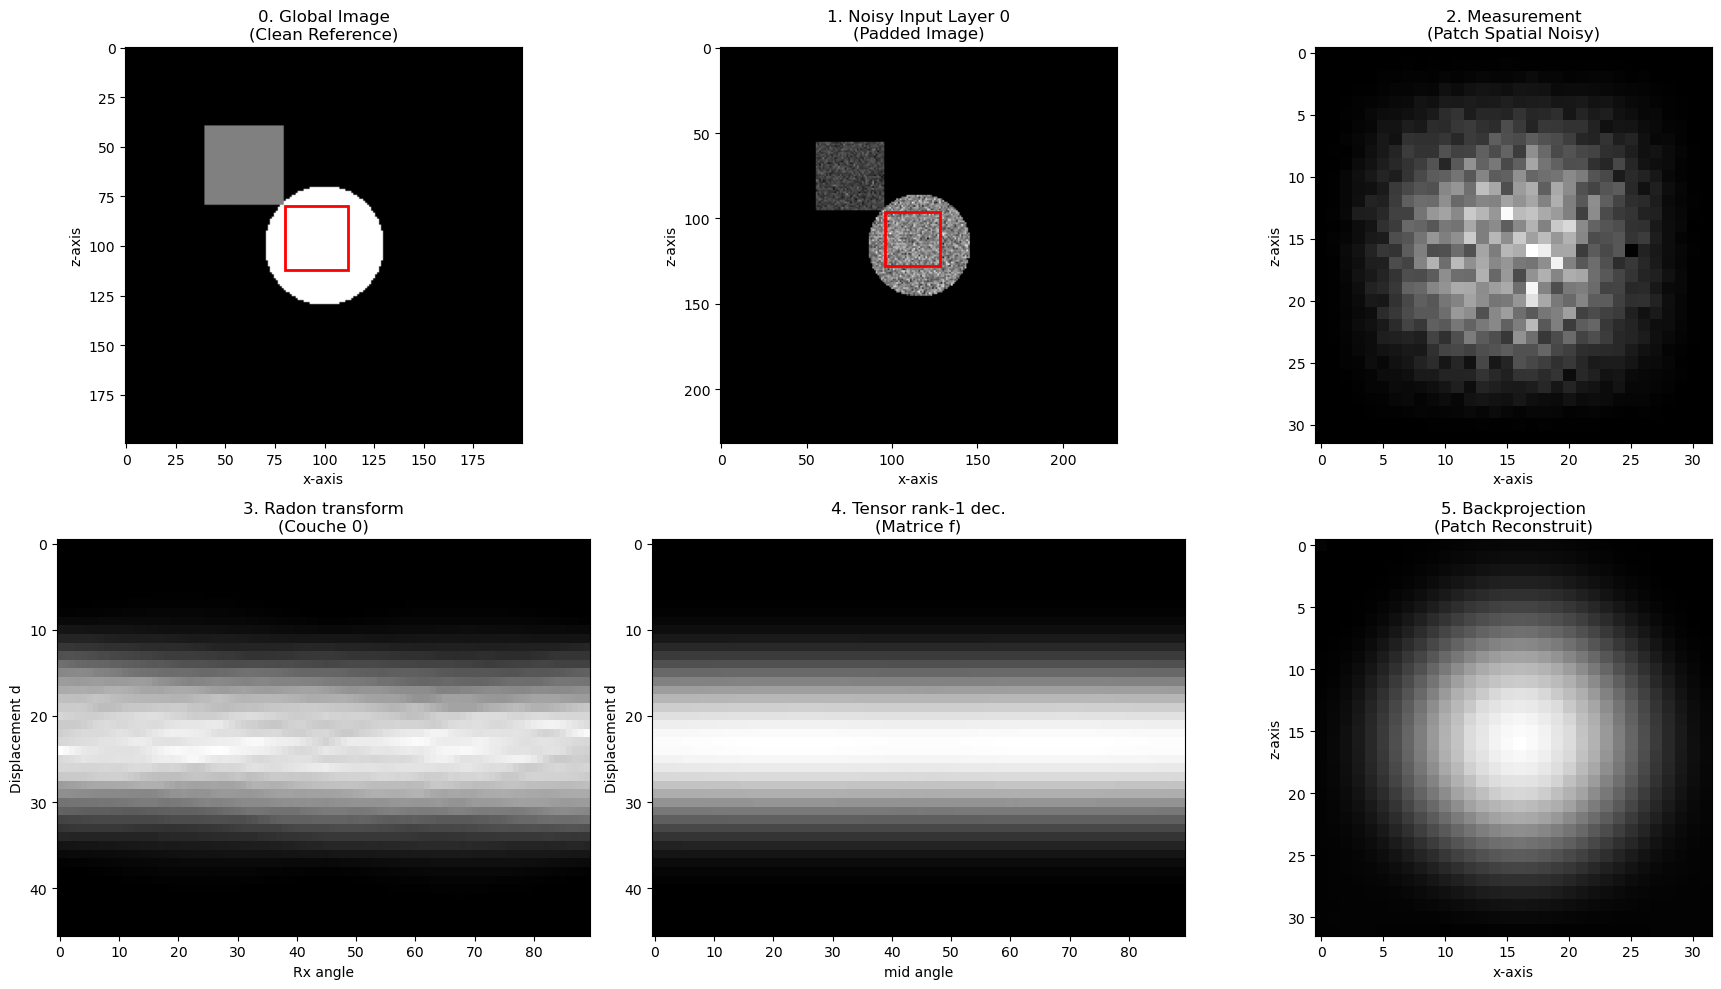

Traitement du Pipeline: 100%|██████████| 625/625 [00:41<00:00, 15.01patch/s]


--- Terminé ! ---
Taille de l'image de sortie : (200, 200) (Attendue: 200, 200)


In [32]:
reference = np.zeros((200, 200))
rr, cc = disk((100, 100), 30)
reference[rr, cc] = 1
reference[40:80, 40:80] = 0.5

result, tensor = pipeline_sur_image(reference, SNR_db=1)

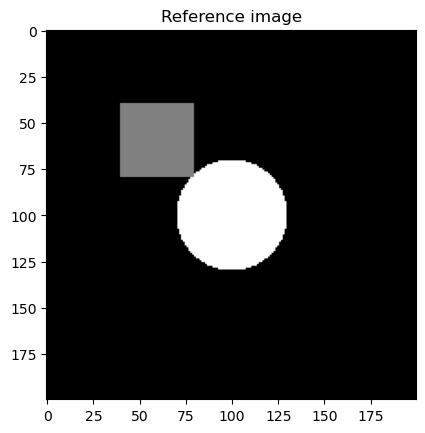

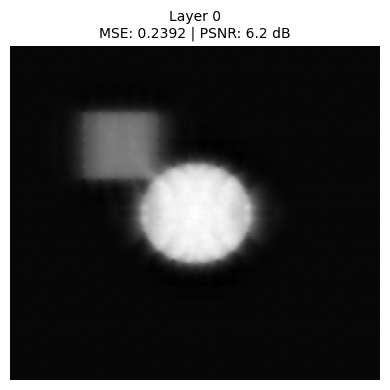

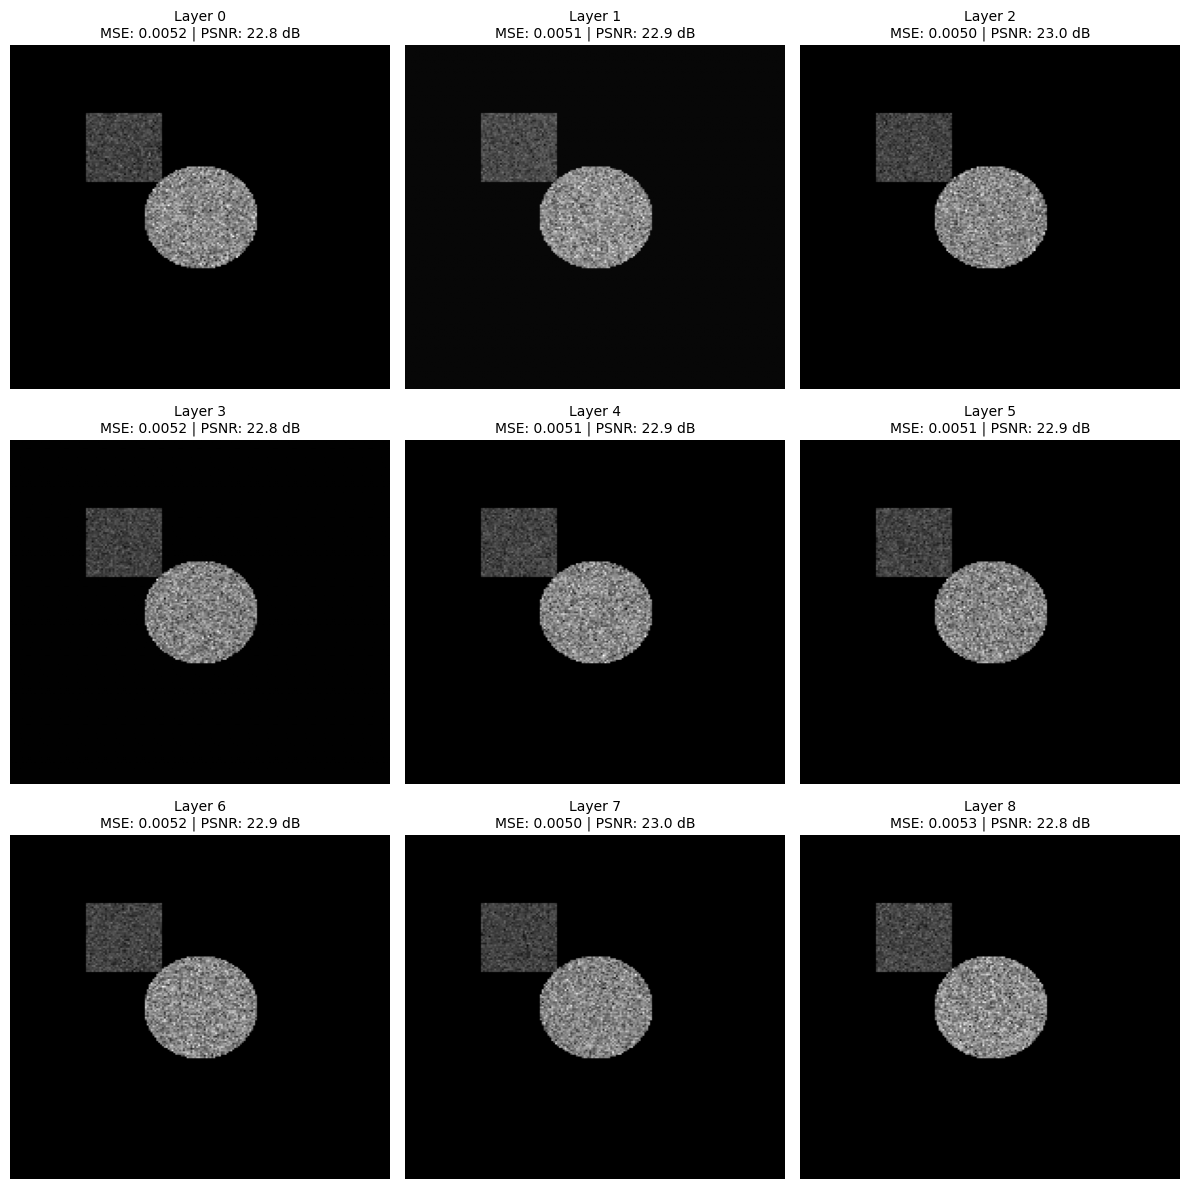

In [33]:
plt.imshow(reference, cmap='gray')
plt.title("Reference image")
plt.show()

afficher_tenseur_3d(result[:,:,np.newaxis], reference=reference)
afficher_tenseur_3d(tensor, reference=reference)

Génération des données...
SNR cible : 1 dB -> Écart-type du bruit généré : 0.2208

Lancement du pipeline sur un tenseur (960, 960, 9)...


Traitement du Pipeline:  50%|█████     | 7260/14400 [07:03<06:42, 17.74patch/s]

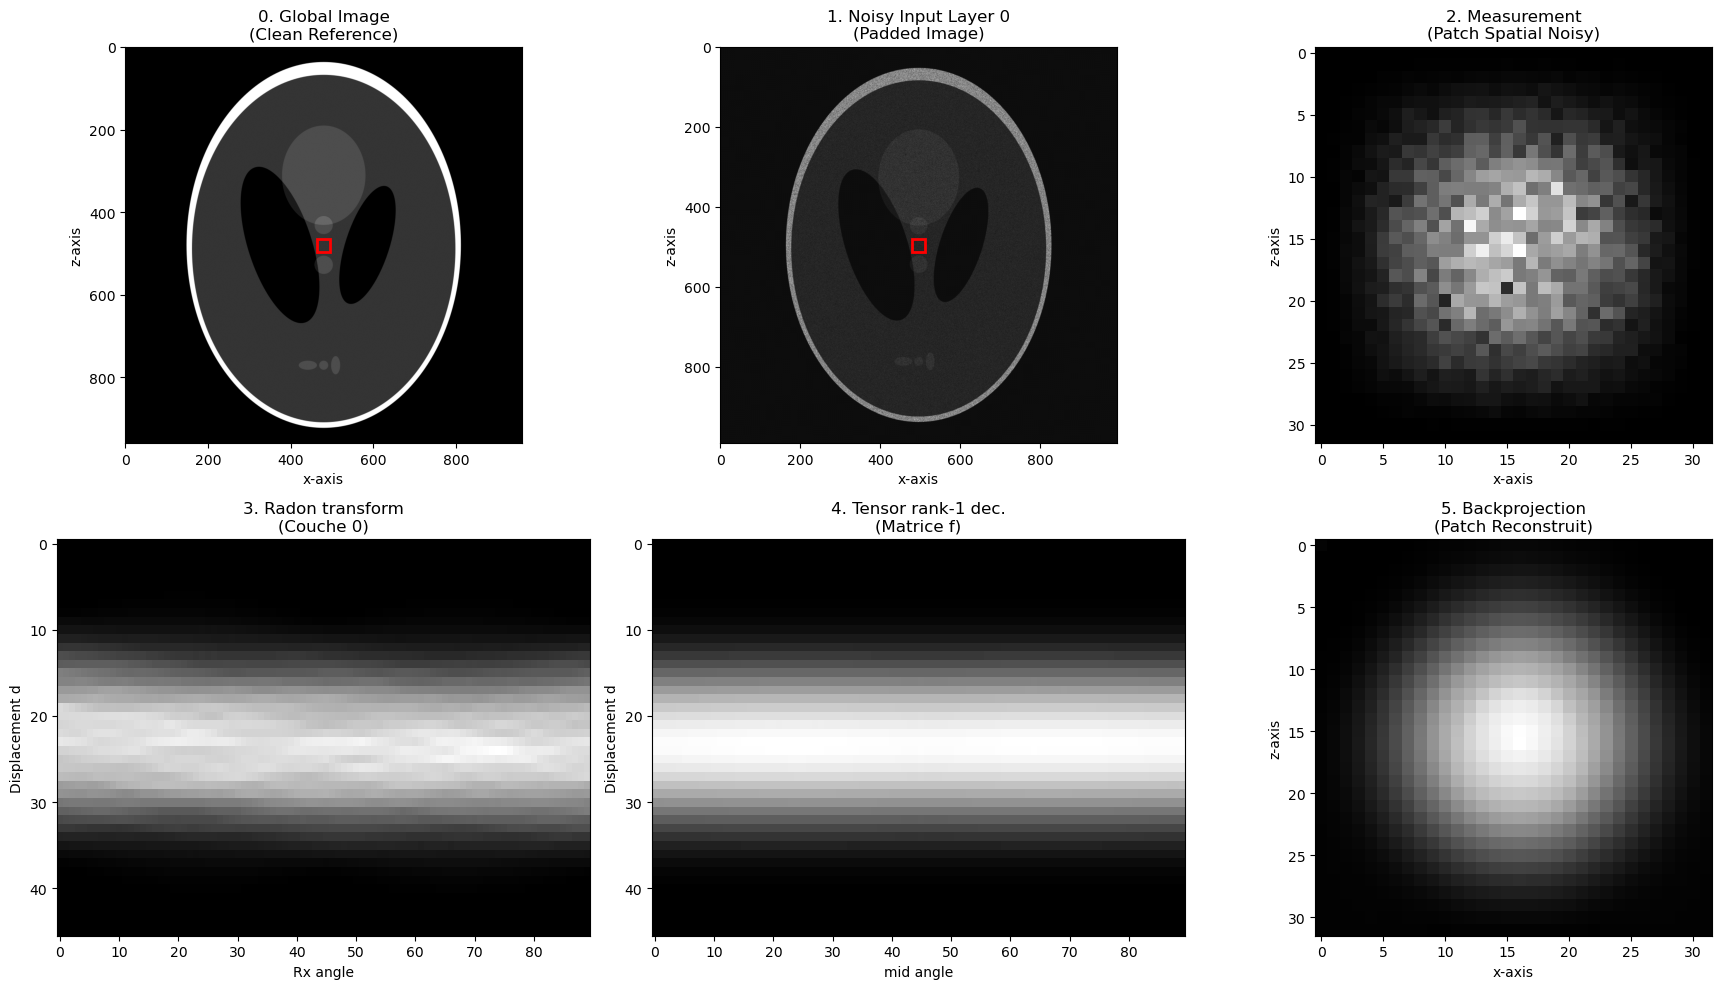

Traitement du Pipeline: 100%|██████████| 14400/14400 [14:16<00:00, 16.82patch/s]


--- Terminé ! ---
Taille de l'image de sortie : (960, 960) (Attendue: 960, 960)


In [51]:
shepp_logan = plt.imread("../data/tensor_decomposition/SheppLogan_Phantom.png")
result, tensor = pipeline_sur_image(shepp_logan, SNR_db=1, layers=9)

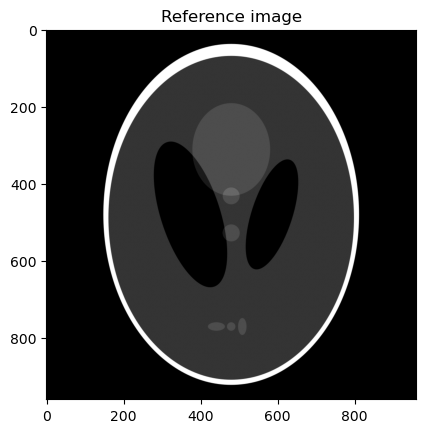

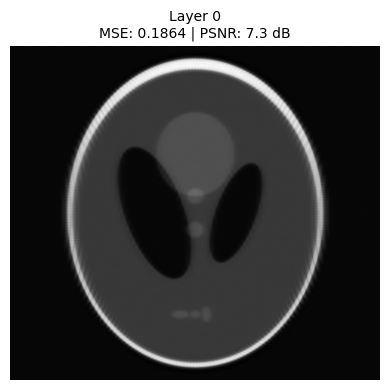

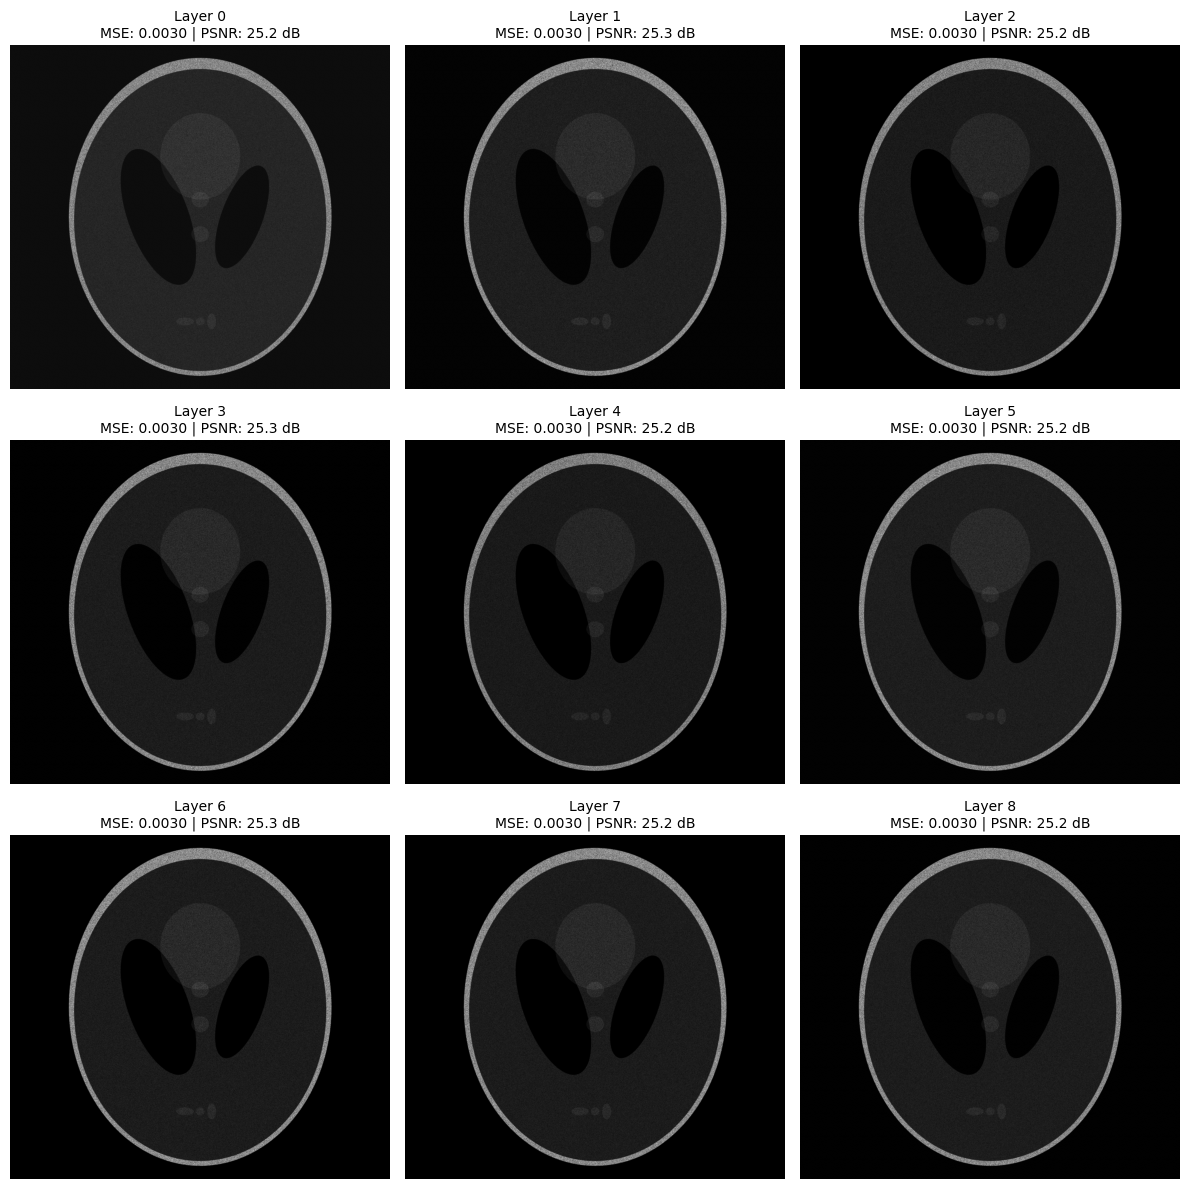

In [52]:
plt.imshow(shepp_logan, cmap='gray')
plt.title("Reference image")
plt.show()

afficher_tenseur_3d(result[:,:,np.newaxis], reference=shepp_logan)
afficher_tenseur_3d(tensor, reference=shepp_logan)